<a href="https://colab.research.google.com/github/kevtheprogrammer/pytorch_starter/blob/main/Nueral_Network.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [4]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline


In [5]:
# create a model class that inherits nn.module
class Model(nn.Module):
  """Input layer (4 layers) --> Hidden layer1(no. nuerons) --> Hidden layer2 (no. neurons) --> output"""
  def __init__(self, in_features=4, h1=8, h2=8, out_features=3):
    super().__init__()
    self.fc1 = nn.Linear(in_features, h1)
    self.fc2 = nn.Linear(h1, h2)
    self.out = nn.Linear(h2, out_features)

  def foward(self,x):
    x = F.relu(self.fc1(x))
    x = F.relu(self.fc2(x))
    x = self.out(x)

    return x

In [6]:
# pick a random seed for randomization
torch.manual_seed(41)
model = Model()

In [7]:
url = 'https://gist.githubusercontent.com/netj/8836201/raw/6f9306ad21398ea43cba4f7d537619d0e07d5ae3/iris.csv'
df = pd.read_csv(url)
# df

In [8]:
df['variety'] = df['variety'].replace('Setosa', 0.0)
df['variety'] = df['variety'].replace('Versicolor', 1.0)
df['variety'] = df['variety'].replace('Virginica', 2.0)


/tmp/ipykernel_679/2447056077.py:3: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['variety'] = df['variety'].replace('Virginica', 2.0)


In [9]:
# train test and split! set x, y

X = df.drop('variety',axis=1)
y = df['variety']

# convert to numpy
X = X.values
y = y.values

from sklearn.model_selection import train_test_split



In [10]:

X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=.2, random_state=41)
# convert x features to float long
x_train = torch.FloatTensor(X_train)
x_test = torch.FloatTensor(X_test)
y_train = torch.LongTensor(y_train)
y_test = torch.LongTensor(y_test)

# measure error
criterian = nn.CrossEntropyLoss()
# use Adam optimizer
optimizer = torch.optim.Adam(model.parameters(), lr=.01)


In [15]:
epoch = 200 # number of times to run through train data
losses = []
for i in range(epoch):
  # get a prediction
  y_pred = model.foward(x_train)
  loss = criterian(y_pred, y_train)
  losses.append(loss.detach().numpy())
  if i % 10 == 0:
    print(f'Epoch: {i}, loss:{loss}')

  # back propergration
  optimizer.zero_grad()
  loss.backward()
  optimizer.step()

Epoch: 0, loss:0.01004797499626875
Epoch: 10, loss:0.009665225632488728
Epoch: 20, loss:0.009264114312827587
Epoch: 30, loss:0.008994015865027905
Epoch: 40, loss:0.008708013221621513
Epoch: 50, loss:0.008434628136456013
Epoch: 60, loss:0.008172240108251572
Epoch: 70, loss:0.007917283102869987
Epoch: 80, loss:0.007669785991311073
Epoch: 90, loss:0.007429713383316994
Epoch: 100, loss:0.0071968077681958675
Epoch: 110, loss:0.0069709522649645805
Epoch: 120, loss:0.006752009503543377
Epoch: 130, loss:0.0065446156077086926
Epoch: 140, loss:0.00799531675875187
Epoch: 150, loss:0.006937796249985695
Epoch: 160, loss:0.006041590590029955
Epoch: 170, loss:0.005806279834359884
Epoch: 180, loss:0.0056427777744829655
Epoch: 190, loss:0.00549132889136672


Text(0.5, 0, 'epoch')

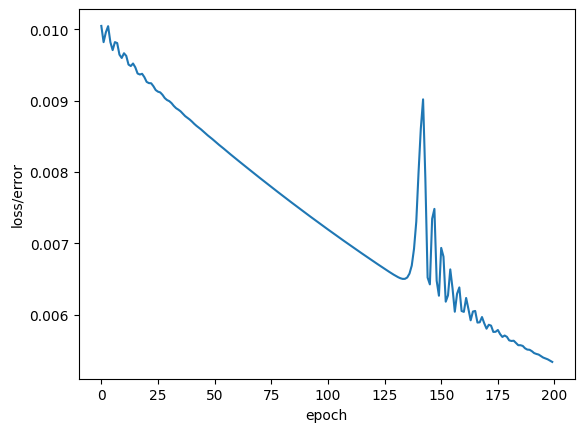

In [16]:
plt.plot(range(epoch), losses)
plt.ylabel('loss/error')
plt.xlabel('epoch')